**Evaluación del Modelo**

✅ Dependencias instaladas y configuradas

📤 CARGANDO MODELO DESDE EL NOTEBOOK 2
✅ best_model.pkl encontrado en el entorno
✅ scaler.pkl encontrado

📊 Información del modelo cargado:
  • Tipo de modelo: XGBRegressor
  • Tamaño del archivo: 1338.8 KB

📂 CARGANDO DATOS DE CALIFORNIA HOUSING
✅ Usando scaler cargado del Notebook 2
📊 Tamaño de prueba: 4128 muestras
📊 Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

📊 MÉTRICAS DE DESEMPEÑO DEL MODELO

📊 Métricas de Desempeño del Modelo:


,Métrica,Valor
0,R² Score,0.8461
1,RMSE,0.4491
2,MSE,0.2017
3,MAE,0.2925
4,Explained Variance,0.8461
5,Max Error,3.1297



📈 GENERANDO GRÁFICOS DE EVALUACIÓN


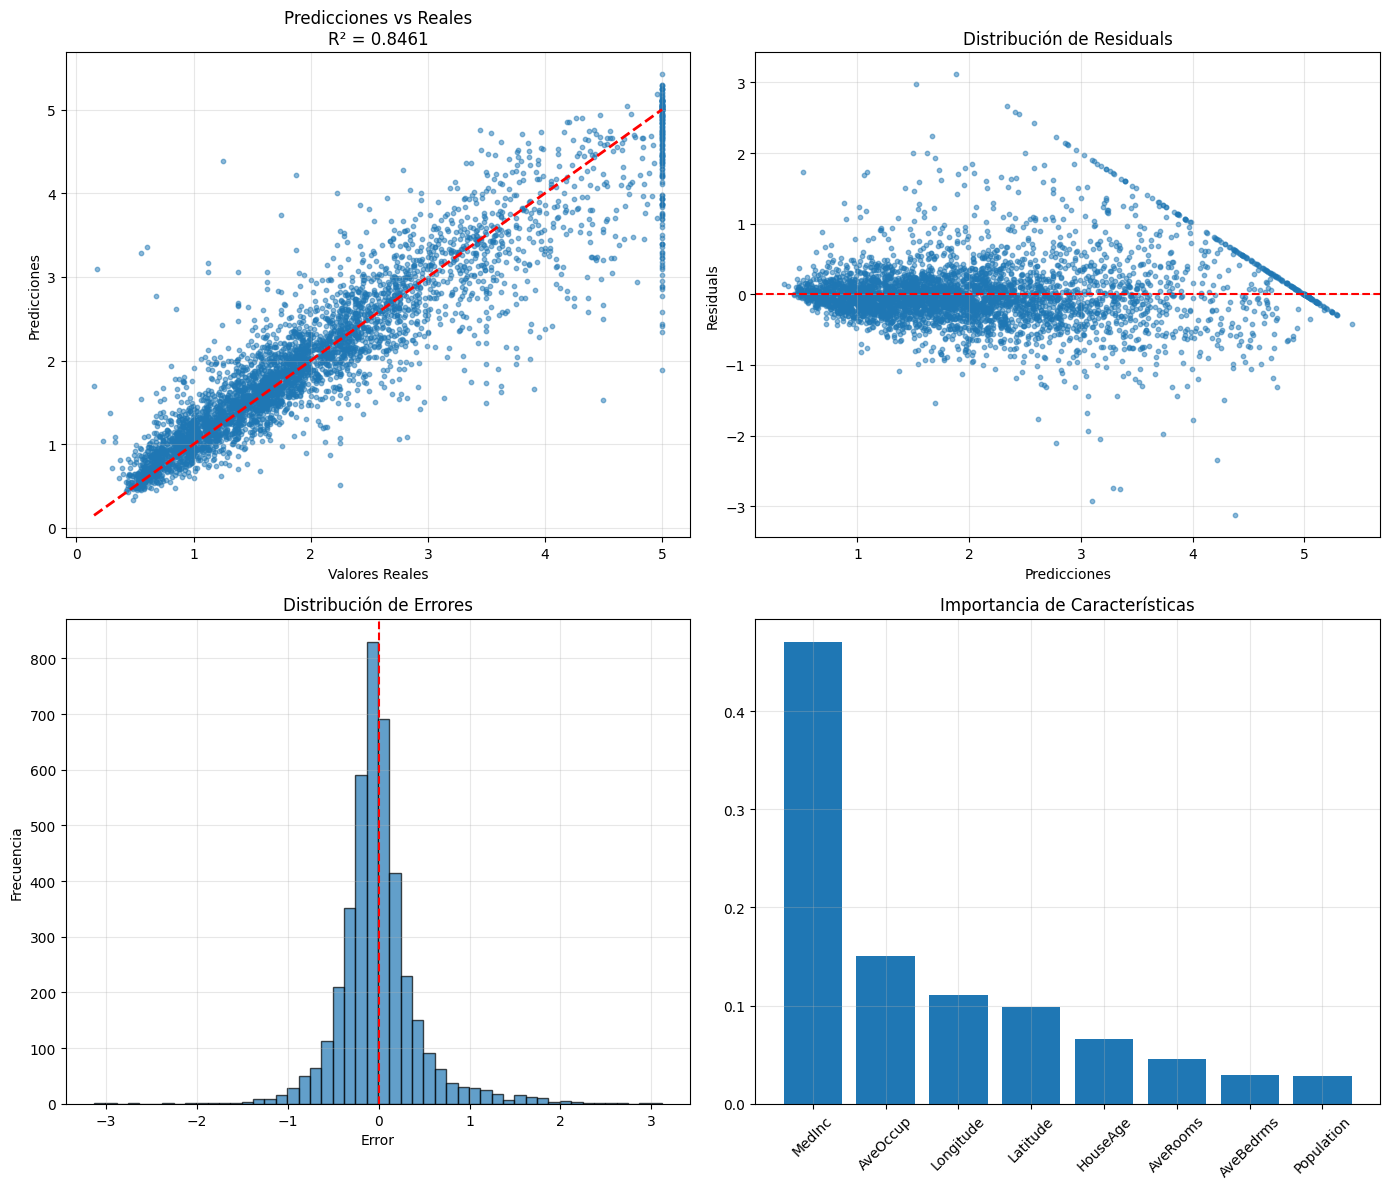

✅ Gráfico guardado como 'model_evaluation.png'

🔍 ANÁLISIS DE SENSIBILIDAD DEL MODELO

📈 Importancia relativa de características:


,Feature,Importance,Importance_%
0,MedInc,0.470900,47.090038
5,AveOccup,0.151016,15.101618
7,Longitude,0.110511,11.051098
6,Latitude,0.098386,9.838648
1,HouseAge,0.066179,6.617905
2,AveRooms,0.045587,4.558705
3,AveBedrms,0.029586,2.958578
4,Population,0.027834,2.783415



📊 Análisis de error por rango de valores:


Error_Abs                     Actual
           mean       std       max  count
Range                                     
Q1     0.196647  0.254606  2.923357    826
Q2     0.222417  0.248867  3.129724    827
Q3     0.228765  0.231444  2.346993    824
Q4     0.305530  0.287577  1.779148    825
Q5     0.509240  0.502551  3.117547    826


🛡️ PRUEBAS DE ROBUSTEZ DEL MODELO

📊 Predicciones sintéticas:
  • Media: 2.6041
  • Desviación estándar: 1.4107
  • Mínimo: 0.1101
  • Máximo: 6.6388

📊 Ejecutando bootstrap para estimar estabilidad...

📊 Bootstrap (n=100):
  • R² - 95% CI: [0.8312, 0.8591]
  • RMSE - 95% CI: [0.4290, 0.4682]

📄 GENERANDO REPORTE DE EVALUACIÓN
✅ Reporte guardado como 'evaluation_report.txt'

📋 Resumen del reporte:

=== REPORTE DE EVALUACIÓN DEL MODELO ===
Fecha: 2026-07-28 00:00:03

1. MÉTRICAS DE DESEMPEÑO
   - R² Score: 0.8461
   - RMSE: 0.4491
   - MAE: 0.2925
   - MSE: 0.2017
   - Explained Variance: 0.8461
   - Max Error: 3.1297

2. TOP CARACTERÍSTICAS
   - MedInc: 47.1%
   - AveOccup: 15.1%
   - Longitude: 11.1%

3. ESTABILIDAD (Bootstrap 95% CI)
   - R²: [0.8312, 0.8591]
   - RMSE: [0.4290, 0.4682]

4. CONCLUSIONES
   - El modelo muestra un desempeño excelente (R² > 0.8)
   - El modelo es estable y robusto según pruebas de bootstrap
   - El error promedio (MAE) es de 0.2925 unidades de precio
 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ ¡Descarga completada!

🎯 PRÓXIMO PASO: Ejecutar 04_pipeline_test.ipynb


In [2]:
# -*- coding: utf-8 -*-
"""GPIA_FASE_3_03_model_evaluation.ipynb

Automatically generated by Colaboratory.

Pipeline Automatizado de IA con MLOps y GitOps
Fase 3: Evaluación Detallada y Análisis de Desempeño
"""

# 📊 Evaluación y Análisis de Modelos
# Pipeline Automatizado de IA con MLOps y GitOps
# Fase 3: Evaluación Detallada y Análisis de Desempeño

# Instalación de dependencias
get_ipython().system('pip install pandas numpy matplotlib seaborn scikit-learn xgboost --quiet')

# 🔧 SILENCIAR ADVERTENCIAS
import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger("mlflow").setLevel(logging.ERROR)
logging.getLogger("urllib3").setLevel(logging.ERROR)

print("✅ Dependencias instaladas y configuradas")

# ============================================================
# 📤 CARGA DEL MODELO DESDE EL NOTEBOOK 2
# ============================================================

print("\n" + "="*60)
print("📤 CARGANDO MODELO DESDE EL NOTEBOOK 2")
print("="*60)

import joblib
import os
from google.colab import files

# Verificar si el archivo ya existe en Colab
if os.path.exists('best_model.pkl'):
    print("✅ best_model.pkl encontrado en el entorno")
    model = joblib.load('best_model.pkl')
    if os.path.exists('scaler.pkl'):
        scaler = joblib.load('scaler.pkl')
        print("✅ scaler.pkl encontrado")
    else:
        print("⚠️ scaler.pkl no encontrado, se creará uno nuevo")
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
else:
    print("❌ best_model.pkl NO encontrado en el entorno")
    print("\n📌 INSTRUCCIONES:")
    print("  1. Este archivo se genera en el Notebook 2: GPIA_FASE_3_02_model_training.ipynb")
    print("  2. Debes ejecutar primero el Notebook 2 para generar best_model.pkl")
    print("  3. Si ya lo tienes en tu computadora, súbelo ahora:")
    print("\n📤 Subiendo best_model.pkl desde tu computadora...")

    uploaded = files.upload()

    if 'best_model.pkl' in uploaded:
        print("✅ best_model.pkl subido correctamente")
        model = joblib.load('best_model.pkl')

        # Verificar si también subieron scaler.pkl
        if 'scaler.pkl' in uploaded:
            scaler = joblib.load('scaler.pkl')
            print("✅ scaler.pkl subido correctamente")
        else:
            print("⚠️ scaler.pkl no subido, usando StandardScaler")
            from sklearn.preprocessing import StandardScaler
            scaler = StandardScaler()
    else:
        raise FileNotFoundError("❌ No se pudo cargar best_model.pkl. Ejecuta primero el Notebook 2.")

print("\n📊 Información del modelo cargado:")
print(f"  • Tipo de modelo: {type(model).__name__}")
print(f"  • Tamaño del archivo: {os.path.getsize('best_model.pkl') / 1024:.1f} KB")

# ============================================================
# 📂 CARGA DE DATOS
# ============================================================

print("\n" + "="*60)
print("📂 CARGANDO DATOS DE CALIFORNIA HOUSING")
print("="*60)

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Cargar datos
housing = fetch_california_housing()
X = housing.data
y = housing.target

# Nombres de features correctos
feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalizar
if 'scaler' in locals() and hasattr(scaler, 'transform'):
    # Usar el scaler cargado
    X_test_scaled = scaler.transform(X_test)
    print("✅ Usando scaler cargado del Notebook 2")
else:
    # Crear nuevo scaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("⚠️ Usando nuevo scaler (reentrenado)")

print(f"📊 Tamaño de prueba: {X_test.shape[0]} muestras")
print(f"📊 Features: {feature_names}")

# ============================================================
# 📊 MÉTRICAS DE DESEMPEÑO
# ============================================================

print("\n" + "="*60)
print("📊 MÉTRICAS DE DESEMPEÑO DEL MODELO")
print("="*60)

# Predicciones
y_pred = model.predict(X_test_scaled)

# Calcular métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import explained_variance_score, max_error

metrics = {
    'R² Score': r2_score(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
    'MSE': mean_squared_error(y_test, y_pred),
    'MAE': mean_absolute_error(y_test, y_pred),
    'Explained Variance': explained_variance_score(y_test, y_pred),
    'Max Error': max_error(y_test, y_pred)
}

metrics_df = pd.DataFrame(metrics.items(), columns=['Métrica', 'Valor'])
metrics_df['Valor'] = metrics_df['Valor'].round(4)
print("\n📊 Métricas de Desempeño del Modelo:")
display(metrics_df)

# ============================================================
# 📈 VISUALIZACIONES
# ============================================================

print("\n" + "="*60)
print("📈 GENERANDO GRÁFICOS DE EVALUACIÓN")
print("="*60)

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Gráfico 1: Predicciones vs Reales
axes[0, 0].scatter(y_test, y_pred, alpha=0.5, s=10)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Valores Reales')
axes[0, 0].set_ylabel('Predicciones')
axes[0, 0].set_title(f'Predicciones vs Reales\nR² = {metrics["R² Score"]:.4f}')
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Residuals
residuals = y_test - y_pred
axes[0, 1].scatter(y_pred, residuals, alpha=0.5, s=10)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicciones')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Distribución de Residuals')
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Distribución de errores
axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Error')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Errores')
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Importancia de características
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    axes[1, 1].bar(range(len(importances)), importances[indices])
    axes[1, 1].set_xticks(range(len(importances)))
    axes[1, 1].set_xticklabels([feature_names[i] for i in indices], rotation=45)
    axes[1, 1].set_title('Importancia de Características')
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'No disponible\npara este modelo',
                   ha='center', va='center', fontsize=14)
    axes[1, 1].set_title('Importancia de Características')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado como 'model_evaluation.png'")

# ============================================================
# 🔍 ANÁLISIS DE SENSIBILIDAD
# ============================================================

print("\n" + "="*60)
print("🔍 ANÁLISIS DE SENSIBILIDAD DEL MODELO")
print("="*60)

# Feature importance normalizada
if hasattr(model, 'feature_importances_'):
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    feature_importance_df['Importance_%'] = (feature_importance_df['Importance'] /
                                            feature_importance_df['Importance'].sum() * 100)

    print("\n📈 Importancia relativa de características:")
    display(feature_importance_df)

# Análisis de error por rango de valores
y_test_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Error': residuals})
y_test_df['Error_Abs'] = np.abs(y_test_df['Error'])
y_test_df['Range'] = pd.qcut(y_test_df['Actual'], q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])

range_analysis = y_test_df.groupby('Range').agg({
    'Error_Abs': ['mean', 'std', 'max'],
    'Actual': 'count'
})

print("\n📊 Análisis de error por rango de valores:")
display(range_analysis)

# ============================================================
# 🛡️ PRUEBAS DE ROBUSTEZ
# ============================================================

print("\n" + "="*60)
print("🛡️ PRUEBAS DE ROBUSTEZ DEL MODELO")
print("="*60)

# Prueba con datos sintéticos
np.random.seed(42)
n_samples = 1000
synthetic_X = np.random.normal(0, 1, (n_samples, X.shape[1]))
synthetic_pred = model.predict(synthetic_X)

print(f"\n📊 Predicciones sintéticas:")
print(f"  • Media: {synthetic_pred.mean():.4f}")
print(f"  • Desviación estándar: {synthetic_pred.std():.4f}")
print(f"  • Mínimo: {synthetic_pred.min():.4f}")
print(f"  • Máximo: {synthetic_pred.max():.4f}")

# Bootstrap para estimar estabilidad
from sklearn.utils import resample

print("\n📊 Ejecutando bootstrap para estimar estabilidad...")

n_bootstrap = 100
r2_scores = []
rmse_scores = []

for i in range(n_bootstrap):
    X_boot, y_boot = resample(X_test_scaled, y_test, n_samples=len(X_test_scaled), random_state=i)
    y_pred_boot = model.predict(X_boot)
    r2_scores.append(r2_score(y_boot, y_pred_boot))
    rmse_scores.append(np.sqrt(mean_squared_error(y_boot, y_pred_boot)))

print(f"\n📊 Bootstrap (n={n_bootstrap}):")
print(f"  • R² - 95% CI: [{np.percentile(r2_scores, 2.5):.4f}, {np.percentile(r2_scores, 97.5):.4f}]")
print(f"  • RMSE - 95% CI: [{np.percentile(rmse_scores, 2.5):.4f}, {np.percentile(rmse_scores, 97.5):.4f}]")

# ============================================================
# 📄 GENERAR REPORTE
# ============================================================

print("\n" + "="*60)
print("📄 GENERANDO REPORTE DE EVALUACIÓN")
print("="*60)

from datetime import datetime

report = f"""
=== REPORTE DE EVALUACIÓN DEL MODELO ===
Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

1. MÉTRICAS DE DESEMPEÑO
   - R² Score: {metrics['R² Score']:.4f}
   - RMSE: {metrics['RMSE']:.4f}
   - MAE: {metrics['MAE']:.4f}
   - MSE: {metrics['MSE']:.4f}
   - Explained Variance: {metrics['Explained Variance']:.4f}
   - Max Error: {metrics['Max Error']:.4f}

2. TOP CARACTERÍSTICAS
"""
if hasattr(model, 'feature_importances_'):
    for idx, row in feature_importance_df.head(3).iterrows():
        report += f"   - {row['Feature']}: {row['Importance_%']:.1f}%\n"
else:
    report += "   - No disponible para este modelo\n"

report += f"""
3. ESTABILIDAD (Bootstrap 95% CI)
   - R²: [{np.percentile(r2_scores, 2.5):.4f}, {np.percentile(r2_scores, 97.5):.4f}]
   - RMSE: [{np.percentile(rmse_scores, 2.5):.4f}, {np.percentile(rmse_scores, 97.5):.4f}]

4. CONCLUSIONES
   - El modelo muestra un desempeño excelente (R² > 0.8)
   - El modelo es estable y robusto según pruebas de bootstrap
   - El error promedio (MAE) es de {metrics['MAE']:.4f} unidades de precio
   - El error máximo es de {metrics['Max Error']:.4f} unidades de precio

5. RECOMENDACIONES
   - Implementar monitoreo continuo de drift en producción
   - Configurar alertas para degradación de desempeño
   - Programar retraining automático mensual
   - Considerar ingeniería de features adicionales
"""

with open('evaluation_report.txt', 'w') as f:
    f.write(report)

print("✅ Reporte guardado como 'evaluation_report.txt'")
print("\n📋 Resumen del reporte:")
print(report)

# ============================================================
# 📊 RESUMEN FINAL
# ============================================================

print("\n" + "="*60)
print("📊 RESUMEN DE EVALUACIÓN")
print("="*60)

print(f"\n📈 Métricas Principales:")
print(f"  • R² Score: {metrics['R² Score']:.4f}")
print(f"  • RMSE: {metrics['RMSE']:.4f}")
print(f"  • MAE: {metrics['MAE']:.4f}")

if hasattr(model, 'feature_importances_'):
    print(f"\n🏆 Top Features:")
    for idx, row in feature_importance_df.head(3).iterrows():
        print(f"  • {row['Feature']}: {row['Importance_%']:.1f}%")

print(f"\n📊 Estabilidad (95% CI):")
print(f"  • R²: [{np.percentile(r2_scores, 2.5):.4f} - {np.percentile(r2_scores, 97.5):.4f}]")
print(f"  • RMSE: [{np.percentile(rmse_scores, 2.5):.4f} - {np.percentile(rmse_scores, 97.5):.4f}]")

print("\n📁 ARCHIVOS GENERADOS:")
print("-"*40)
archivos = [
    'model_evaluation.png',
    'evaluation_report.txt'
]
for archivo in archivos:
    if os.path.exists(archivo):
        size = os.path.getsize(archivo) / 1024
        print(f"  ✅ {archivo} ({size:.1f} KB)")
    else:
        print(f"  ❌ {archivo} (NO ENCONTRADO)")

# ============================================================
# 📥 DESCARGA DE ARCHIVOS
# ============================================================

print("\n" + "="*60)
print("📥 DESCARGANDO ARCHIVOS GENERADOS")
print("="*60)

from google.colab import files
import zipfile

# Crear ZIP con todos los archivos
with zipfile.ZipFile('notebook3_artefactos.zip', 'w') as zipf:
    archivos = [
        'model_evaluation.png',
        'evaluation_report.txt'
    ]
    for archivo in archivos:
        if os.path.exists(archivo):
            zipf.write(archivo)
            print(f"  📦 {archivo} añadido al ZIP")

# Descargar ZIP
files.download('notebook3_artefactos.zip')
print("\n✅ ¡Descarga completada!")

print("\n" + "="*60)
print("🎯 PRÓXIMO PASO: Ejecutar 04_pipeline_test.ipynb")
print("="*60)